# Somnotate Scoring and Inspection
Score EDF recordings by subject and date, then save predictions.

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from utils.scoring import score_recordings
from utils.visualization import plot_scoring_detailed, plot_state_distributions
%matplotlib qt

model_name = "test_model_2"
repo_root = Path.cwd().parent
model_path = (
    repo_root
    / "data"
    / "hypnose_eeg"
    / "derivatives"
    / "somnotate_training"
    / model_name
    / "model.pickle"
)

In [ ]:
subjids = [63, 64, 65]
dates = [20260715]
# date_range = (20260501, 20260510)

outputs = score_recordings(
    subjids=subjids,
    dates=dates,
    model_path=model_path,
    repo_root=repo_root,
)

for path in outputs:
    print("Saved predictions:", path)

FileNotFoundError: Derivatives root not found at /Volumes/harris/hypnose/hypnose_eeg/derivatives. Create a symlink named 'derivatives' in the repo.

# Visualization for Scored Subjects

1. Plot Scoring Detailed: 
- Plots raw EMG, raw EEG, Delta, Theta, T:D Ratio, EMG RMS 
- Plots Somnotate-scored states below
- All in interactive visualizer

2. Plot State Distributions: 
- One plot for: Theta, Delta, T:D Ratio, EMG RMS
- In each, normalized distribution for NREM, REM, and Wake is shown
- Allows to judge if Somnotate scoring is plausible

In [5]:
viz_subjid = "65"
viz_date = "20260715"

In [ ]:
# Visualize a single scored recording (one subject and one date).
# Detailed view: EEG/EMG raw, EMG RMS, delta & theta envelopes, theta:delta ratio,
# plus the somnotate state row. Pass manual_vectors={"scorer": vec, ...} to overlay
# human scorers and shade mismatch regions.
fig, viewer = plot_scoring_detailed(
    subjid=viz_subjid,
    date=viz_date,
    repo_root=repo_root,
    recording_index=0,
    manual_vectors=None,   # optional: {"human": human_vec}
    eeg_channel=0,
    view_length_s=120.0,
)


Loading sub-065_ses-001_recording-001_2026-07-15_11_06_32.edf…
Computing metrics for sub-065_ses-001_recording-001_2026-07-15_11_06_32.edf…

[sub-065 date-20260715] sub-065_ses-001_recording-001_2026-07-15_11_06_32.edf
State occupancy (of 170687 scored Wake/NREM/REM 1s epochs):
  Wake :  43.6%   (14892 analysis epochs of 5s)
  NREM :  49.5%   (16909 analysis epochs of 5s)
  REM  :   6.8%   (2335 analysis epochs of 5s)


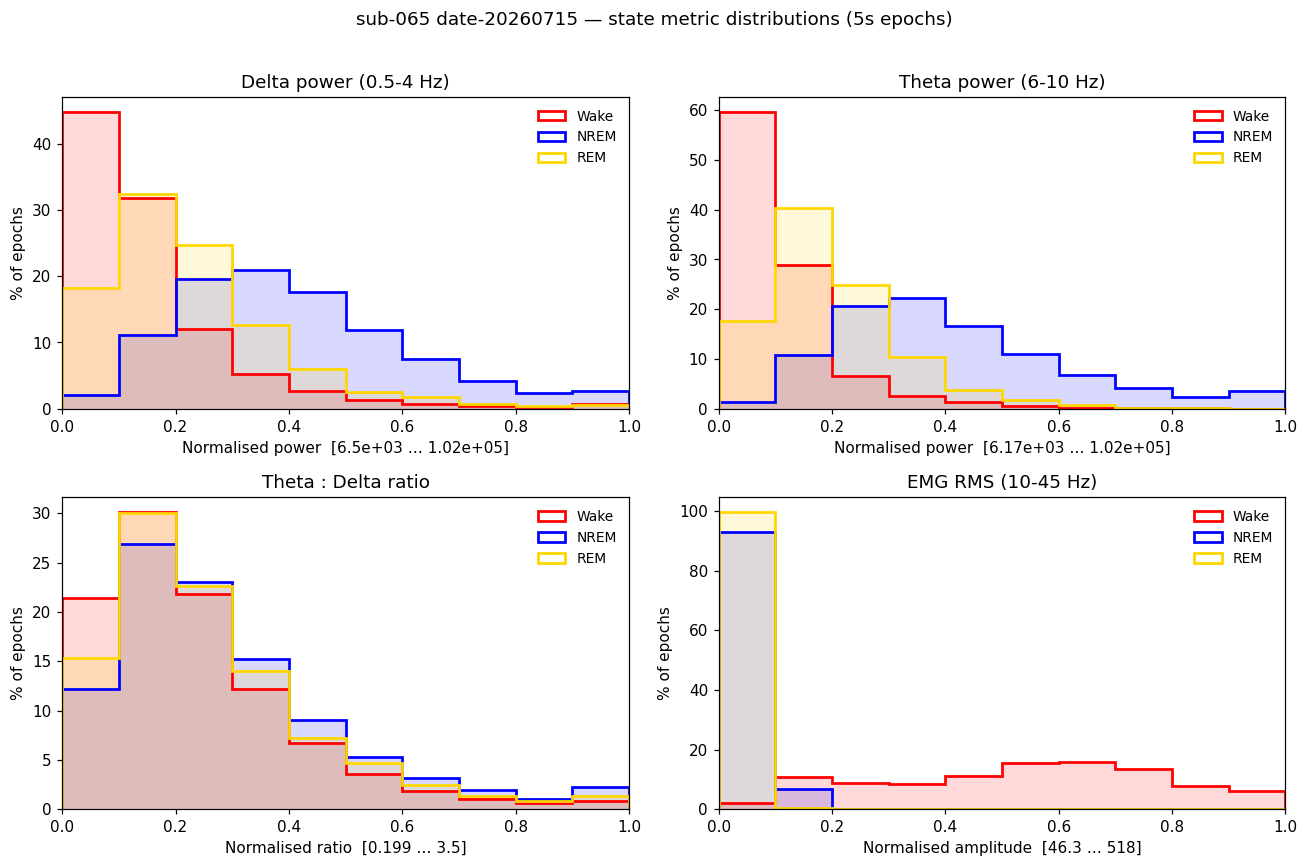

In [6]:
# Per-state metric distributions for one scored recording.
# Splits the recording into Wake/NREM/REM, stitches each state's signal, epochs it
# (epoch_length_s), and histograms delta power, theta power, theta:delta ratio, and
# EMG RMS per state (Wake=red, NREM=blue, REM=yellow). Prints time spent per state.
sessions = plot_state_distributions(
    subjid=viz_subjid,
    date=viz_date,
    repo_root=repo_root,
    epoch_length_s=5.0,
    bin_width=0.1 #Resolution of bins on x axis
)
